<a href="https://colab.research.google.com/github/Opsimtech/CFD-ML-model/blob/main/Flettner_PINN_Cleanv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flettner Rotor PINN — Clean v3
**Re=3.6e5, α=2.0. Laminar → k-ω SST. 6 cells in order.**

Run cells 1→2→3→4→5→6 in order. Do not skip any.

In [1]:
# ── CELL 1: Parameters ───────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os, numpy as np, pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size":11, "figure.dpi":120})

RE    = 3.6e5
NU    = 1.0 / RE
ALPHA = 2.0
D     = 1.0
R_IN  = D / 2
R_OUT = 25.0 * D

EPOCHS  = 4000
LR      = 1e-4

W_PDE   = 100.0
W_VWALL = 200.0
W_VFF   =  10.0
W_PP    =  50.0
W_CP    =   5.0
W_TURB  =   1.0

N_INT  = 2000
N_WALL =  300
N_FF   =  150

DATA_DIR = "/content/drive/MyDrive/P-PINN"
OUT_DIR  = "/content/drive/MyDrive/PINN_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"TF {tf.__version__} | GPU: {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Re={RE:.1e}  alpha={ALPHA}  nu={NU:.3e}")
print("Cell 1 done ✓")


Mounted at /content/drive
TF 2.20.0 | GPU: True
Re=3.6e+05  alpha=2.0  nu=2.778e-06
Cell 1 done ✓


In [2]:
# ── CELL 2: Load data ────────────────────────────────────────────
RE_COL_MAP = {
    1.8e5:{0,12,24,36,48,60}, 2.5e5:{3,15,27,39,51,63,69,75,81,87,93},
    3.6e5:{6,18,30,42,54,72,78,84,90,96}, 1.0e6:{9,21,33,45,57,66},
}

def load_cp(folder, re_target, alpha_target, tol=0.1):
    for nm in ["CP_data.xlsx","CP data.xlsx"]:
        p = os.path.join(folder, nm)
        if os.path.exists(p): break
    raw  = pd.read_excel(p, sheet_name="Master Data", header=None)
    row0 = raw.iloc[0]
    for col in range(0, len(row0)-1, 3):
        label = str(row0.iloc[col])
        if "k =" not in label: continue
        try: k_val = float(label.split(",")[0].replace("k =","").strip())
        except: continue
        if abs(k_val - alpha_target) > tol: continue
        re_match = None
        for rv, cs in RE_COL_MAP.items():
            if col in cs: re_match = rv; break
        if re_match is None or abs(re_match-re_target) > re_target*0.1: continue
        th = pd.to_numeric(raw.iloc[2:,col],   errors="coerce").values
        cp = pd.to_numeric(raw.iloc[2:,col+1], errors="coerce").values
        mask = ~np.isnan(th) & ~np.isnan(cp)
        if mask.sum() < 3: continue
        return th[mask].astype(np.float32), cp[mask].astype(np.float32)
    raise ValueError(f"No Cp data for alpha={alpha_target}, Re={re_target:.2e}")

def load_cl_cd(folder, re_target):
    sheet = {1.8e5:"Re=1.8e5",2.5e5:"Re=2.5e5",3.6e5:"Re=3.6e5",
             5.5e5:"Re=5.5e5",1.0e6:"Re=1e6"}[
             min({1.8e5,2.5e5,3.6e5,5.5e5,1.0e6},key=lambda r:abs(r-re_target))]
    for nm in ["CL_data.xlsx","CL data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): cl_path=p; break
    for nm in ["CD_data.xlsx","CD data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): cd_path=p; break
    df_cl=pd.read_excel(cl_path,sheet_name=sheet,header=None)
    df_cd=pd.read_excel(cd_path,sheet_name=sheet,header=None)
    df_cl.columns=["alpha","CL"]+list(df_cl.columns[2:])
    df_cd.columns=["alpha","CD"]+list(df_cd.columns[2:])
    return (df_cl["alpha"].dropna().values.astype(np.float32),
            df_cl["CL"].dropna().values.astype(np.float32),
            df_cd["alpha"].dropna().values.astype(np.float32),
            df_cd["CD"].dropna().values.astype(np.float32))

print("Loading data...")
theta_exp, cp_exp = load_cp(DATA_DIR, RE, ALPHA)
al_cl, CL_exp, al_cd, CD_exp = load_cl_cd(DATA_DIR, RE)
tol = 0.25
cl_ref = float(CL_exp[np.abs(al_cl-ALPHA)<tol].mean())
cd_ref = float(CD_exp[np.abs(al_cd-ALPHA)<tol].mean())
print(f"  Cp: {len(theta_exp)} pts  stag@{theta_exp[np.argmax(cp_exp)]:.0f}°  suction@{theta_exp[np.argmin(cp_exp)]:.0f}°")
print(f"  Exp: CL={cl_ref:.3f}  CD={cd_ref:.3f}")
print("Cell 2 done ✓")


Loading data...
  Cp: 30 pts  stag@331°  suction@109°
  Exp: CL=5.917  CD=1.745
Cell 2 done ✓


In [4]:
# ── CELL 3: Model and sampling ───────────────────────────────────
import tensorflow as tf
tf.keras.backend.clear_session()

# Build model
inp  = tf.keras.Input(shape=(3,), name="xya")
h    = inp
for _ in range(6):
    h = tf.keras.layers.Dense(64, activation="tanh")(h)
uvp  = tf.keras.layers.Dense(3, activation=None,       name="uvp")(h)
komg = tf.keras.layers.Dense(2, activation="softplus", name="komg")(h)
model = tf.keras.Model(inputs=inp, outputs=[uvp, komg])
print(f"Model: {model.count_params():,} parameters")
print("  Input:  (x, y, alpha/5)")
print("  Output: uvp=(u,v,p)   komg=(k,omega) via softplus")

# Helpers to unpack model outputs
def get_uvp(out): return out[0]
def get_ko(out):  return out[1]

# SST constants (Menter 1994 outer set)
NU_TF     = tf.constant(float(NU),   dtype=tf.float32)
BETA_STAR = tf.constant(0.09,        dtype=tf.float32)
BETA2     = tf.constant(0.0828,      dtype=tf.float32)
SIGMA_K2  = tf.constant(1.00,        dtype=tf.float32)
SIGMA_O2  = tf.constant(0.856,       dtype=tf.float32)
GAMMA2    = tf.constant(0.0828/0.09 - 0.856*0.41**2/0.09**0.5, dtype=tf.float32)
EPS_T     = tf.constant(1e-8,        dtype=tf.float32)
K_WALL    = tf.constant(0.0,         dtype=tf.float32)
OMG_WALL  = tf.constant(60.0*float(NU), dtype=tf.float32)
K_INF     = tf.constant(1.5e-4,      dtype=tf.float32)
OMG_INF   = tf.constant(2.0,         dtype=tf.float32)

# Sampling
def make_xy(x, y):
    a = np.full_like(x, ALPHA/5.0, dtype=np.float32)
    return tf.constant(np.hstack([x, y, a]))

def sample_interior(n):
    th = np.random.uniform(0, 2*np.pi, n).astype(np.float32)
    r  = np.exp(np.random.uniform(np.log(R_IN), np.log(R_OUT), n)).astype(np.float32)
    return (r*np.cos(th)).reshape(-1,1), (r*np.sin(th)).reshape(-1,1)

def sample_wall(n):
    # Bordogna: theta=0=windward(x=-R), theta=90=top(y=+R)
    # x = -R*cos(th),  y = +R*sin(th)
    th = np.linspace(0, 2*np.pi, n, endpoint=False, dtype=np.float32)
    return (-R_IN*np.cos(th)).reshape(-1,1), (+R_IN*np.sin(th)).reshape(-1,1)

def sample_ff(n):
    th = np.linspace(0, 2*np.pi, n, endpoint=False, dtype=np.float32)
    return (R_OUT*np.cos(th)).reshape(-1,1), (R_OUT*np.sin(th)).reshape(-1,1)

def mse(a, b=0.0):
    return tf.reduce_mean(tf.square(a - b))

# Pre-compute fixed points
Omega = float(ALPHA / R_IN)
xw, yw = sample_wall(N_WALL)
u_wall = tf.constant(( Omega * yw).astype(np.float32))
v_wall = tf.constant((-Omega * xw).astype(np.float32))
xff, yff = sample_ff(N_FF)
xff_tf   = make_xy(xff, yff)

# Cp sensor coordinates: x=-R*cos(th), y=+R*sin(th)
th_rad_exp = np.radians(theta_exp).astype(np.float32)
x_cp = (-R_IN * np.cos(th_rad_exp)).reshape(-1,1)
y_cp = (+R_IN * np.sin(th_rad_exp)).reshape(-1,1)
xy_cp_tf = make_xy(x_cp, y_cp)
cp_targ  = tf.constant(cp_exp.reshape(-1,1))

print(f"Omega={Omega:.2f}  u_wall=[{float(u_wall.numpy().min()):.2f},{float(u_wall.numpy().max()):.2f}]")
print("Cell 3 done ✓")


Model: 21,381 parameters
  Input:  (x, y, alpha/5)
  Output: uvp=(u,v,p)   komg=(k,omega) via softplus
Omega=4.00  u_wall=[-2.00,2.00]
Cell 3 done ✓


In [5]:
# ── CELL 4: Training ─────────────────────────────────────────────
# Phase 1 (ep 0-1000):    laminar NS only
# Phase 2 (ep 1000-2000): k-omega ramps in linearly
# Phase 3 (ep 2000-4000): full k-omega SST
import time

optimizer = tf.keras.optimizers.Adam(LR)
EPS_FD    = 1e-3
xw_tf     = make_xy(xw, yw)

history = {"loss":[],"pde":[],"wall":[],"cp":[],"turb":[],"epoch":[]}
best_loss, best_w = np.inf, None

print(f"Training {EPOCHS} epochs")
print("  ep 0-1000:    laminar (turb off)")
print("  ep 1000-2000: turbulence ramps in")
print("  ep 2000-4000: full k-omega SST")
t0 = time.time()

for ep in range(EPOCHS):
    x_int, y_int = sample_interior(N_INT)
    xy_var = tf.Variable(make_xy(x_int, y_int), trainable=False, dtype=tf.float32)
    tr = float(min(1.0, max(0.0, (ep-1000)/1000.0)))
    turb_tf = tf.constant(tr, dtype=tf.float32)

    with tf.GradientTape() as tape:

        # 1st derivatives
        with tf.GradientTape(watch_accessed_variables=False,
                             persistent=True) as inner:
            inner.watch(xy_var)
            out_int = model(xy_var, training=True)
            uvp_int = get_uvp(out_int)
            u,v,p   = uvp_int[:,0:1], uvp_int[:,1:2], uvp_int[:,2:3]
            if tr > 0:
                ko  = get_ko(out_int)
                k   = ko[:,0:1] + EPS_T
                omg = ko[:,1:2] + EPS_T
        du_dxy=inner.gradient(u,xy_var); dv_dxy=inner.gradient(v,xy_var)
        dp_dxy=inner.gradient(p,xy_var)
        du_dx=du_dxy[:,0:1]; du_dy=du_dxy[:,1:2]
        dv_dx=dv_dxy[:,0:1]; dv_dy=dv_dxy[:,1:2]
        dp_dx=dp_dxy[:,0:1]; dp_dy=dp_dxy[:,1:2]
        del inner

        # Eddy viscosity
        nu_t  = turb_tf*tf.clip_by_value(k/(omg+EPS_T),0.,0.1) if tr>0 else tf.constant(0.)
        nu_eff = NU_TF + nu_t

        # 2nd derivatives via FD
        dX=tf.constant(np.hstack([np.full((N_INT,1),EPS_FD),np.zeros((N_INT,1)),np.zeros((N_INT,1))]).astype(np.float32))
        dY=tf.constant(np.hstack([np.zeros((N_INT,1)),np.full((N_INT,1),EPS_FD),np.zeros((N_INT,1))]).astype(np.float32))
        oxp=model(xy_var+dX,training=True); oxm=model(xy_var-dX,training=True)
        oyp=model(xy_var+dY,training=True); oym=model(xy_var-dY,training=True)
        uxp=get_uvp(oxp); uxm=get_uvp(oxm); uyp=get_uvp(oyp); uym=get_uvp(oym)
        ie2=1./(EPS_FD**2)
        d2u_dx2=(uxp[:,0:1]-2*u+uxm[:,0:1])*ie2; d2u_dy2=(uyp[:,0:1]-2*u+uym[:,0:1])*ie2
        d2v_dx2=(uxp[:,1:2]-2*v+uxm[:,1:2])*ie2; d2v_dy2=(uyp[:,1:2]-2*v+uym[:,1:2])*ie2

        # NS residuals
        r_cont=du_dx+dv_dy
        r_xmom=u*du_dx+v*du_dy+dp_dx-nu_eff*(d2u_dx2+d2u_dy2)
        r_ymom=u*dv_dx+v*dv_dy+dp_dy-nu_eff*(d2v_dx2+d2v_dy2)
        loss_pde=mse(r_cont)+mse(r_xmom)+mse(r_ymom)

        # k-omega transport
        loss_turb=tf.constant(0.)
        if tr > 0:
            kxp=get_ko(oxp);kxm=get_ko(oxm);kyp=get_ko(oyp);kym=get_ko(oym)
            inv2=.5/EPS_FD
            dk_dx=(kxp[:,0:1]-kxm[:,0:1])*inv2; dk_dy=(kyp[:,0:1]-kym[:,0:1])*inv2
            do_dx=(kxp[:,1:2]-kxm[:,1:2])*inv2; do_dy=(kyp[:,1:2]-kym[:,1:2])*inv2
            d2k_dx2=(kxp[:,0:1]-2*k+kxm[:,0:1])*ie2; d2k_dy2=(kyp[:,0:1]-2*k+kym[:,0:1])*ie2
            d2o_dx2=(kxp[:,1:2]-2*omg+kxm[:,1:2])*ie2; d2o_dy2=(kyp[:,1:2]-2*omg+kym[:,1:2])*ie2
            S2=2*(du_dx**2+dv_dy**2)+(du_dy+dv_dx)**2
            Pk=tf.clip_by_value(nu_t*S2,0.,20.*BETA_STAR*k*omg)
            nk=NU_TF+SIGMA_K2*nu_t; no=NU_TF+SIGMA_O2*nu_t
            crs=2.*SIGMA_O2/(omg+EPS_T)*(dk_dx*do_dx+dk_dy*do_dy)
            rk=u*dk_dx+v*dk_dy-Pk+BETA_STAR*omg*k-nk*(d2k_dx2+d2k_dy2)
            ro=u*do_dx+v*do_dy-GAMMA2*(omg/(k+EPS_T))*Pk+BETA2*omg**2-no*(d2o_dx2+d2o_dy2)-crs
            loss_turb=turb_tf*(mse(tf.clip_by_value(rk,-100.,100.))+
                               mse(tf.clip_by_value(ro,-100.,100.)))

        # Wall BC
        out_w=model(xw_tf,training=True); uvp_w=get_uvp(out_w)
        loss_wall=mse(uvp_w[:,0:1],u_wall)+mse(uvp_w[:,1:2],v_wall)
        if tr>0:
            ko_w=get_ko(out_w)
            loss_wall=loss_wall+turb_tf*(mse(ko_w[:,0:1],K_WALL)+mse(ko_w[:,1:2],OMG_WALL))

        # Far-field BC + pressure ref
        out_ff=model(xff_tf,training=True); uvp_ff=get_uvp(out_ff)
        loss_ff=mse(uvp_ff[:,0:1],1.)+mse(uvp_ff[:,1:2])
        p_ff_mean=tf.reduce_mean(uvp_ff[:,2:3])
        loss_pp=tf.square(p_ff_mean)
        if tr>0:
            ko_ff=get_ko(out_ff)
            loss_ff=loss_ff+turb_tf*(mse(ko_ff[:,0:1],K_INF)+mse(ko_ff[:,1:2],OMG_INF))

        # Cp data
        out_cp=model(xy_cp_tf,training=True); uvp_cp=get_uvp(out_cp)
        cp_pred=2.*(uvp_cp[:,2:3]-p_ff_mean)
        loss_cp=mse(cp_pred,cp_targ)

        loss=(W_PDE*loss_pde+W_VWALL*loss_wall+W_VFF*loss_ff+
              W_PP*loss_pp+W_CP*loss_cp+W_TURB*loss_turb)

    grads=tape.gradient(loss,model.trainable_variables)
    grads,_=tf.clip_by_global_norm(grads,5.)
    optimizer.apply_gradients(zip(grads,model.trainable_variables))

    L=float(loss)
    if not np.isnan(L) and L<best_loss:
        best_loss=L; best_w=model.get_weights()

    if ep%500==0:
        phase="TURB" if tr>0 else "lam "
        history["loss"].append(L); history["pde"].append(float(loss_pde))
        history["wall"].append(float(loss_wall)); history["cp"].append(float(loss_cp))
        history["turb"].append(float(loss_turb)); history["epoch"].append(ep)
        print(f"  ep {ep:5d} [{phase} r={tr:.2f}] L={L:.3f} "
              f"pde={float(loss_pde):.4f} wall={float(loss_wall):.4f} "
              f"cp={float(loss_cp):.4f} turb={float(loss_turb):.4f} | {time.time()-t0:.0f}s")

    if ep==2000: optimizer.learning_rate.assign(3e-5); print("  LR→3e-5")

print(f"\nDone {(time.time()-t0)/60:.1f} min | best={best_loss:.4f}")
if best_w: model.set_weights(best_w)
model.save_weights(f"{OUT_DIR}/M1_turb.weights.h5")
print("Saved ✓  —  run Cell 5 to see results")


Training 4000 epochs
  ep 0-1000:    laminar (turb off)
  ep 1000-2000: turbulence ramps in
  ep 2000-4000: full k-omega SST


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['komg/kernel', 'komg/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


  ep     0 [lam  r=0.00] L=975.661 pde=0.0216 wall=4.5405 cp=9.6975 turb=0.0000 | 3s
  ep   500 [lam  r=0.00] L=18.459 pde=0.0628 wall=0.0119 cp=1.5363 turb=0.0000 | 141s
  ep  1000 [lam  r=0.00] L=13.259 pde=0.0634 wall=0.0095 cp=0.9604 turb=0.0000 | 275s
  ep  1500 [TURB r=0.50] L=22.332 pde=0.0575 wall=0.0153 cp=0.7511 turb=0.2802 | 449s
  ep  2000 [TURB r=1.00] L=14.245 pde=0.0589 wall=0.0083 cp=0.4902 turb=0.3106 | 621s
  LR→3e-5
  ep  2500 [TURB r=1.00] L=9.357 pde=0.0445 wall=0.0061 cp=0.3672 turb=0.2171 | 796s
  ep  3000 [TURB r=1.00] L=6.603 pde=0.0333 wall=0.0045 cp=0.2569 turb=0.1594 | 967s
  ep  3500 [TURB r=1.00] L=5.250 pde=0.0307 wall=0.0030 cp=0.1697 turb=0.1391 | 1137s

Done 21.8 min | best=3.7668
Saved ✓  —  run Cell 5 to see results


Computing...
Forces:
  Pressure drag:  +1.6875
  Viscous drag:   +0.0000
  Pressure lift:  +4.7427
  Viscous lift:   +0.0000

  CL=4.743 (exp=5.917)
  CD=1.688 (exp=1.745)
  Cp MAE=0.271  Cp_min=-5.72@103°
  Cp_max=1.04@334°  L/D=2.81


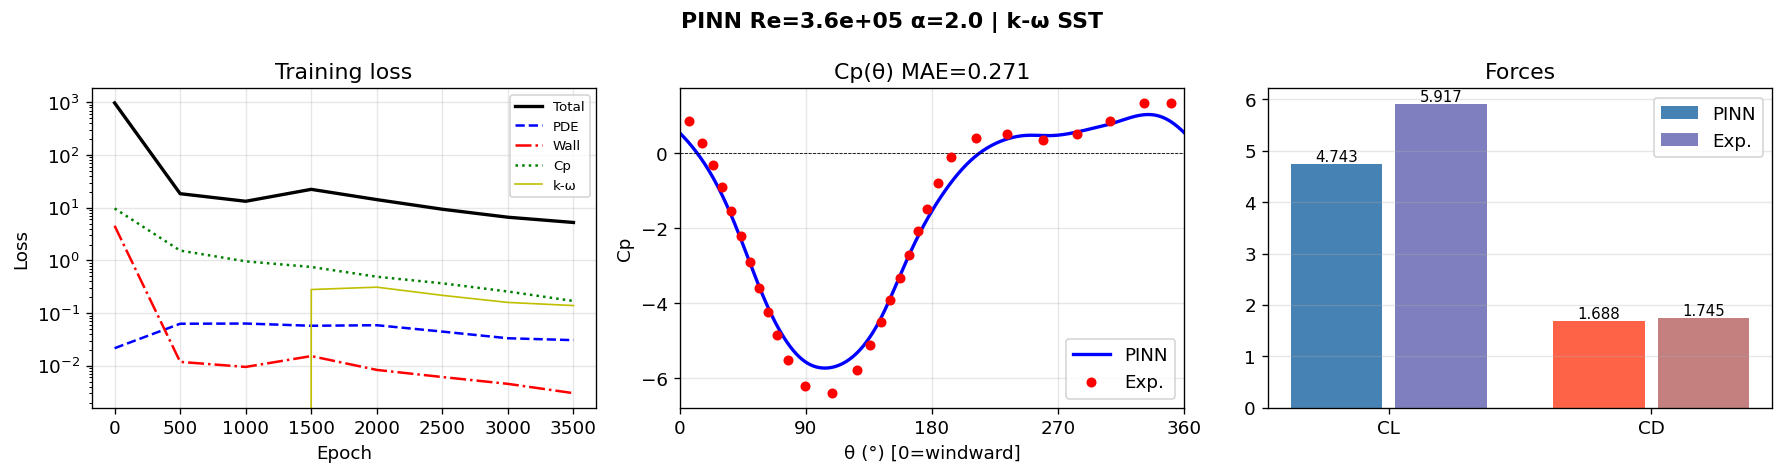

CD ✓ positive
Figure saved ✓


In [6]:
# ── CELL 5: Evaluation ───────────────────────────────────────────
def get_pref(n=256):
    th  = np.linspace(0, 2*np.pi, n, dtype=np.float32)
    xy  = make_xy((R_OUT*np.cos(th)).reshape(-1,1),
                  (R_OUT*np.sin(th)).reshape(-1,1))
    return float(get_uvp(model(xy,training=False)).numpy()[:,2].mean())

def predict_cp(n=360):
    """Bordogna: x=-R*cos(th), y=+R*sin(th)"""
    th_deg = np.linspace(0,360,n,dtype=np.float32)
    th_rad = np.radians(th_deg)
    x = (-R_IN*np.cos(th_rad)).reshape(-1,1)
    y = (+R_IN*np.sin(th_rad)).reshape(-1,1)
    uvp = get_uvp(model(make_xy(x,y),training=False)).numpy()
    Cp  = 2.*(uvp[:,2] - get_pref())
    return th_deg, Cp

def compute_forces(n=512):
    nu_v=float(NU); eps=1e-3; dth=2*np.pi/n
    th  = np.linspace(0,2*np.pi,n,endpoint=False,dtype=np.float32)
    x   = (-R_IN*np.cos(th)).reshape(-1,1)
    y   = (+R_IN*np.sin(th)).reshape(-1,1)
    nx  = x/R_IN; ny = y/R_IN   # outward normal = position/R
    pr  = get_pref()
    def uv(xp,yp):
        o=get_uvp(model(make_xy(xp,yp),training=False)).numpy()
        return o[:,0:1],o[:,1:2],o[:,2:3]
    u0,v0,p0=uv(x,y); p0-=pr
    uxp,vxp,_=uv(x+eps,y); uxm,vxm,_=uv(x-eps,y)
    uyp,vyp,_=uv(x,y+eps); uym,vym,_=uv(x,y-eps)
    du_dx=(uxp-uxm)/(2*eps); du_dy=(uyp-uym)/(2*eps)
    dv_dx=(vxp-vxm)/(2*eps); dv_dy=(vyp-vym)/(2*eps)
    txx=2*nu_v*du_dx; txy=nu_v*(du_dy+dv_dx); tyy=2*nu_v*dv_dy
    Fp_x=np.sum(-p0*nx*R_IN*dth); Fp_y=np.sum(-p0*ny*R_IN*dth)
    Fv_x=np.sum((txx*nx+txy*ny)*R_IN*dth); Fv_y=np.sum((txy*nx+tyy*ny)*R_IN*dth)
    print(f"  Pressure drag:  {float(Fp_x/0.5):+.4f}")
    print(f"  Viscous drag:   {float(Fv_x/0.5):+.4f}")
    print(f"  Pressure lift:  {float(Fp_y/0.5):+.4f}")
    print(f"  Viscous lift:   {float(Fv_y/0.5):+.4f}")
    return float((Fp_y+Fv_y)/0.5), float((Fp_x+Fv_x)/0.5)

print("Computing...")
th_p,Cp_p = predict_cp()
print("Forces:"); CL_p,CD_p = compute_forces()
Cp_at_exp = np.interp(theta_exp, th_p, Cp_p)
mae = float(np.mean(np.abs(Cp_at_exp-cp_exp)))

print(f"\n{'='*50}")
print(f"  CL={CL_p:.3f} (exp={cl_ref:.3f})")
print(f"  CD={CD_p:.3f} (exp={cd_ref:.3f})")
print(f"  Cp MAE={mae:.3f}  Cp_min={Cp_p.min():.2f}@{th_p[np.argmin(Cp_p)]:.0f}°")
print(f"  Cp_max={Cp_p.max():.2f}@{th_p[np.argmax(Cp_p)]:.0f}°  L/D={CL_p/max(CD_p,.001):.2f}")
print(f"{'='*50}")

fig,axes=plt.subplots(1,3,figsize=(15,4))
ep=history["epoch"]
axes[0].semilogy(ep,history["loss"],"k-",lw=2,label="Total")
axes[0].semilogy(ep,history["pde"],"b--",label="PDE")
axes[0].semilogy(ep,history["wall"],"r-.",label="Wall")
axes[0].semilogy(ep,history["cp"],"g:",label="Cp")
axes[0].semilogy(ep,history["turb"],"y-",lw=1,label="k-ω")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8); axes[0].grid(True,alpha=0.3)
axes[0].set_title("Training loss")

axes[1].plot(th_p,Cp_p,"b-",lw=2,label="PINN")
axes[1].scatter(theta_exp,cp_exp,color="red",s=25,zorder=5,label="Exp.")
axes[1].axhline(0,color="k",lw=0.5,ls="--")
axes[1].set_xlabel("θ (°) [0=windward]"); axes[1].set_ylabel("Cp")
axes[1].set_title(f"Cp(θ) MAE={mae:.3f}")
axes[1].set_xlim([0,360]); axes[1].set_xticks([0,90,180,270,360])
axes[1].legend(); axes[1].grid(True,alpha=0.3)

x_pos=np.arange(2)
axes[2].bar(x_pos-.2,[CL_p,CD_p],.35,label="PINN",color=["steelblue","tomato"])
axes[2].bar(x_pos+.2,[cl_ref,cd_ref],.35,label="Exp.",color=["navy","darkred"],alpha=.5)
for i,(pv,ev) in enumerate(zip([CL_p,CD_p],[cl_ref,cd_ref])):
    axes[2].text(i-.2,max(pv,0)+.05,f"{pv:.3f}",ha="center",fontsize=9)
    axes[2].text(i+.2,max(ev,0)+.05,f"{ev:.3f}",ha="center",fontsize=9)
axes[2].set_xticks(x_pos); axes[2].set_xticklabels(["CL","CD"])
axes[2].axhline(0,color="k",lw=0.5)
axes[2].legend(); axes[2].grid(True,alpha=0.3,axis="y")
axes[2].set_title("Forces")

plt.suptitle(f"PINN Re={RE:.1e} α={ALPHA} | k-ω SST",fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/M1_results.png",bbox_inches="tight",dpi=150)
plt.show()
print(f"CD {'✓ positive' if CD_p>0 else '✗ negative'}")
print(f"Figure saved ✓")
